In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
data=pd.read_csv(r"C:\Users\GOPESHWAR KUMAR\Document\Machine\Project1\JupyterModel\Housing_price.csv")

In [5]:
data.shape

(545, 13)

In [6]:
data.head(3)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished


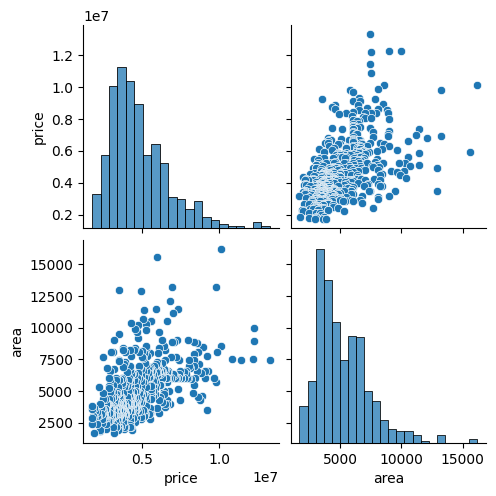

In [7]:
sns.pairplot(data=data[["price" ,"area"]])
plt.show()

In [8]:
# delete column
data.drop("furnishingstatus", axis=1, inplace=True)

In [9]:
# Changing data into numerical form

In [10]:
data["mainroad"] = data["mainroad"].map({"yes": 1, "no": 0})

In [11]:
data["prefarea"] = data["prefarea"].map({"yes": 1, "no": 0})

In [12]:
data["airconditioning"] = data["airconditioning"].map({"yes": 1, "no": 0})

In [13]:
data["guestroom"] = data["guestroom"].map({"yes": 1, "no": 0})

In [14]:
data["hotwaterheating"] = data["hotwaterheating"].map({"yes": 1, "no": 0})

In [15]:
data["basement"] = data["basement"].map({"yes": 1, "no": 0})

In [16]:
data

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea
0,13300000,7420,4,2,3,1,0,0,0,1,2,1
1,12250000,8960,4,4,4,1,0,0,0,1,3,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1
4,11410000,7420,4,1,2,1,1,1,0,1,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,1,0,1,0,0,2,0
541,1767150,2400,3,1,1,0,0,0,0,0,0,0
542,1750000,3620,2,1,1,1,0,0,0,0,0,0
543,1750000,2910,3,1,1,0,0,0,0,0,0,0


In [17]:
data.isnull().sum()

price              0
area               0
bedrooms           0
bathrooms          0
stories            0
mainroad           0
guestroom          0
basement           0
hotwaterheating    0
airconditioning    0
parking            0
prefarea           0
dtype: int64

In [18]:
x = data.drop("price", axis=1)  # drop target from features
y = data["price"]               # target column

In [19]:
scale=StandardScaler()
scale.fit_transform(x)

array([[ 1.04672629,  1.40341936,  1.42181174, ...,  1.4726183 ,
         1.51769249,  1.80494113],
       [ 1.75700953,  1.40341936,  5.40580863, ...,  1.4726183 ,
         2.67940935, -0.55403469],
       [ 2.21823241,  0.04727831,  1.42181174, ..., -0.67906259,
         1.51769249,  1.80494113],
       ...,
       [-0.70592066, -1.30886273, -0.57018671, ..., -0.67906259,
        -0.80574124, -0.55403469],
       [-1.03338891,  0.04727831, -0.57018671, ..., -0.67906259,
        -0.80574124, -0.55403469],
       [-0.5998394 ,  0.04727831, -0.57018671, ..., -0.67906259,
        -0.80574124, -0.55403469]], shape=(545, 11))

In [20]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [21]:
model=LinearRegression()

In [22]:
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [23]:
model.score(x_test,y_test)*100

64.37296086614114

In [24]:
model.score(x_train,y_train)*100

67.81204341087313

In [25]:
model.predict(x_test)

array([5398919.06668406, 7065403.52242257, 2993803.65442489,
       4535814.37095637, 3053270.46119634, 3709351.46814548,
       5440532.08436119, 6228231.2637049 , 2882007.07052161,
       2341077.46202216, 9669446.99384903, 2968606.34038989,
       3313473.96276161, 3298076.7146539 , 3917562.61502005,
       5451316.51696926, 2935783.76577867, 5020968.01587435,
       4611901.50853052, 3459716.25356269, 6031175.37726022,
       5858126.13664539, 2900858.8451071 , 5004989.10270268,
       5250383.45099946, 7582448.67436233, 3446590.61322786,
       5039916.00815844, 8051720.01234678, 3173494.27554285,
       6479223.19419278, 3527946.31942094, 6553367.01960289,
       4111301.41589294, 3752397.72547943, 5797499.44418857,
       4816747.63555382, 4616670.38819151, 3334907.08797079,
       4389155.37405231, 4503752.98075596, 3704757.77375415,
       7046386.68164143, 3784673.66996625, 3637999.13588582,
       4488238.10842619, 6736670.12525002, 3967749.94181508,
       3947022.79857926,

In [26]:
predicted_price = model.predict([[1200, 2, 2, 2, 1, 0, 1, 0, 1, 2, 1]])
print("Predicted House Price: ₹", round(predicted_price[0], 2))

Predicted House Price: ₹ 6230036.39


C:\Users\GOPESHWAR KUMAR\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [27]:
model.coef_

array([2.37710510e+02, 7.84836476e+04, 1.10932614e+06, 4.26909551e+05,
       4.12677757e+05, 2.43606446e+05, 4.35005497e+05, 7.12264653e+05,
       8.08415428e+05, 2.47443135e+05, 6.36787694e+05])

In [28]:
model.intercept_

np.float64(-72427.55025565065)

In [29]:
import pickle

In [32]:
pickle.dump(model, open("Housemodel.pkl" , "wb"))